# 👥 Multi-Agent Environment

We create a grid environment where:

- 2 agents move independently  
- Both agents must reach their respective goals  
- Rewards are given based on success  

👉 This is a **cooperative setting** (no conflict between agents)

---

# 📌 Independent Q-Learning (IQL)

In Independent Q-Learning:

- Each agent learns its **own Q-table**
- Other agents are treated as part of the environment
- There is **no communication** between agents

---

## 🔁 Q-Learning Update Rule

The Q-learning update is given by:

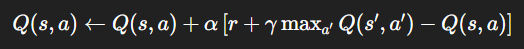
---

## 🧠 Key Idea

Each agent independently:
- Observes the environment state
- Chooses an action
- Receives reward
- Updates its own Q-table

Even though agents act independently, they learn to behave optimally in a shared environment.

In [1]:
import numpy as np
import random

# =========================
# ENVIRONMENT
# =========================

class MultiAgentGrid:
    def __init__(self, size=5):
        self.size = size
        
        # agent positions
        self.agent_pos = {
            0: [0, 0],
            1: [4, 4]
        }
        
        # goals
        self.goal_pos = {
            0: [4, 0],
            1: [0, 4]
        }

    def reset(self):
        self.agent_pos = {
            0: [0, 0],
            1: [4, 4]
        }
        return self._get_state()

    def _get_state(self):
        # state = positions of both agents
        return (tuple(self.agent_pos[0]), tuple(self.agent_pos[1]))

    def step(self, actions):
        rewards = {0: -1, 1: -1}  # small step penalty
        done = {0: False, 1: False}

        for agent_id in [0, 1]:
            move = actions[agent_id]
            x, y = self.agent_pos[agent_id]

            # actions: 0=up,1=down,2=left,3=right
            if move == 0:
                x = max(0, x - 1)
            elif move == 1:
                x = min(self.size - 1, x + 1)
            elif move == 2:
                y = max(0, y - 1)
            elif move == 3:
                y = min(self.size - 1, y + 1)

            self.agent_pos[agent_id] = [x, y]

            # check goal
            if self.agent_pos[agent_id] == self.goal_pos[agent_id]:
                rewards[agent_id] = 10
                done[agent_id] = True

        return self._get_state(), rewards, done


# =========================
# IQL AGENT
# =========================

class IQLAgent:
    def __init__(self, actions=4, alpha=0.1, gamma=0.9, epsilon=0.2):
        self.q_table = {}
        self.actions = actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

    def get_q(self, state):
        if state not in self.q_table:
            self.q_table[state] = np.zeros(self.actions)
        return self.q_table[state]

    def act(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.actions - 1)
        return np.argmax(self.get_q(state))

    def learn(self, state, action, reward, next_state):
        q = self.get_q(state)
        q_next = self.get_q(next_state)

        q[action] = q[action] + self.alpha * (
            reward + self.gamma * np.max(q_next) - q[action]
        )


# =========================
# TRAINING LOOP
# =========================

env = MultiAgentGrid()
agents = {
    0: IQLAgent(),
    1: IQLAgent()
}

episodes = 300

for ep in range(episodes):
    state = env.reset()
    total_reward = {0: 0, 1: 0}

    for step in range(50):
        actions = {
            0: agents[0].act(state),
            1: agents[1].act(state)
        }

        next_state, rewards, done = env.step(actions)

        # learning step for each agent
        for i in [0, 1]:
            agents[i].learn(state, actions[i], rewards[i], next_state)
            total_reward[i] += rewards[i]

        state = next_state

        if all(done.values()):
            break

    if ep % 50 == 0:
        print(f"Episode {ep} | Rewards: {total_reward}")

print("\nTraining completed!")

Episode 0 | Rewards: {0: -50, 1: 148}
Episode 50 | Rewards: {0: 82, 1: -50}
Episode 100 | Rewards: {0: 4, 1: 15}
Episode 150 | Rewards: {0: 5, 1: 27}
Episode 200 | Rewards: {0: 5, 1: 27}
Episode 250 | Rewards: {0: 3, 1: 25}

Training completed!


# 📊 Output Explanation

The training log shows how both agents improve over time in the environment.

- In the early episodes (Episode 0), rewards are unstable because both agents are exploring randomly.
- Some episodes show negative or low rewards because agents take inefficient paths or fail to reach goals.

As training progresses:
- The agents start learning better movement strategies.
- Rewards become more positive and stable over time.
- Both agents begin reaching their goals more efficiently.

### 🔍 Key Observation:
- Agent behavior improves from random exploration → goal-oriented actions
- Final episodes show consistent positive rewards, meaning learning has converged

### 🎯 Final Result:
Both agents successfully learn to navigate the grid and reach their respective goals using Independent Q-Learning.